In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, TimeDistributed, Bidirectional, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import re



In [ ]:
# Load and preprocess dataset
def load_data(file_path):
    sentences, labels = [], []
    with open(file_path, 'r', encoding='utf-8') as file:
        lines = file.readlines()
        sentence, label = [], []
        for line in lines:
            line = line.strip()
            if not line or line.endswith('.'):  # Split on empty lines or sentence-ending punctuation
                if sentence:
                    sentences.append(sentence)
                    labels.append(label)
                    sentence, label = [], []
            matches = re.findall(r'\[(.*?)\]', line)
            for match in matches:
                parts = match.rsplit(':', 1)
                if len(parts) == 2:
                    token, tag = parts
                    sentence.append(token.strip())
                    label.append(tag.strip())
        if sentence:
            sentences.append(sentence)
            labels.append(label)

    print("First 3 parsed sentences:", sentences[:3])
    print("First 3 parsed labels:", labels[:3])
    print("Total sentences parsed:", len(sentences))

    return sentences, labels

# Convert data to integer sequences
def prepare_data(sentences, labels):
    if not sentences or not labels:
        raise ValueError("Error: No data found in sentences or labels.")

    word2idx = {word: idx+1 for idx, word in enumerate(set(word for sent in sentences for word in sent))}
    tag2idx = {tag: idx for idx, tag in enumerate(set(tag for lbl in labels for tag in lbl))}

    print("Vocabulary size:", len(word2idx))
    print("Tag set size:", len(tag2idx))

    X = [[word2idx[word] for word in sent] for sent in sentences]
    y = [[tag2idx[tag] for tag in lbl] for lbl in labels]

    if not X or not y:
        raise ValueError("Error: X or y sequences are empty after token mapping.")

    X = pad_sequences(X, padding='post')
    y = pad_sequences(y, padding='post')

    if y.size == 0:
        raise ValueError("Error: Label array y is empty after padding.")

    y = np.array([to_categorical(lbl, num_classes=len(tag2idx)) for lbl in y])
    return X, y, word2idx, tag2idx

# Load data
file_path = 'part1.txt'
sentences, labels = load_data(file_path)



First 3 parsed sentences: [['shock'], ['peritonitis', 'infection', 'Antibiotics'], ['polyps', 'sigmoidoscopy', 'colonoscopy', 'sigmoidoscopy', 'Polyps', 'polyps', 'polyps', 'sigmoidoscopy', 'polyps', 'colonoscopy', 'polypectomy', 'polyps', 'polyps', 'sigmoidoscopy', 'polyps', 'polyps', 'polyps', 'polyps']]
First 3 parsed labels: [['PROBLEM'], ['PROBLEM', 'CONDITION ; PROBLEM', 'TREATMENT'], ['TEST', 'TEST', 'TEST', 'TEST', 'TEST', 'TEST', 'TEST', 'TEST', 'TEST', 'TEST', 'TREATMENT', 'TEST', 'TEST', 'TEST', 'TEST', 'TEST', 'TEST', 'TEST']]
Total sentences parsed: 2108


In [ ]:

# Debugging: Check the number of sentences and labels again
print("Number of sentences after fix:", len(sentences))
print("First sentence:", sentences[0] if sentences else "No sentences found")
print("Number of labels after fix:", len(labels))
print("First label sequence:", labels[0] if labels else "No labels found")

# Prepare data
X, y, word2idx, tag2idx = prepare_data(sentences, labels)

# Ensure we have enough samples for splitting
if len(sentences) > 1:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
else:
    raise ValueError("Not enough sentences for train-test split. Ensure dataset is correctly formatted.")

# Define BiLSTM model
model = Sequential([
    Embedding(input_dim=len(word2idx)+1, output_dim=50, input_length=X.shape[1]),
    Bidirectional(LSTM(units=100, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)),
    TimeDistributed(Dense(len(tag2idx), activation='softmax'))
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, batch_size=32, epochs=20, validation_split=0.1)



Number of sentences after fix: 2108
First sentence: ['shock']
Number of labels after fix: 2108
First label sequence: ['PROBLEM']
Vocabulary size: 1986
Tag set size: 31


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 30s 402ms/step - accuracy: 0.8737 - loss: 0.6938 - val_accuracy: 0.9305 - val_loss: 0.1773
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 214ms/step - accuracy: 0.9296 - loss: 0.1611 - val_accuracy: 0.9337 - val_loss: 0.1455
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.9407 - loss: 0.1429 - val_accuracy: 0.9497 - val_loss: 0.1338
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 212ms/step - accuracy: 0.9560 - loss: 0.1249 - val_accuracy: 0.9549 - val_loss: 0.1146
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.9642 - loss: 0.0999 - val_accuracy: 0.9637 - val_loss: 0.0935
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 213ms/step - accuracy: 0.9795 - loss: 0.0719 - val_accuracy: 0.9772 - val_loss: 0.0721
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.9895 - loss: 0.0469 - val_accuracy: 0.9808 - val_loss: 0.0554
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 213ms/step - accuracy: 0.9949 - loss: 0.0295 - val_accura

In [ ]:
# Evaluate model
y_pred = model.predict(X_test)
if y_pred.size == 0:
    raise ValueError("Error: Model produced no predictions.")

y_pred_labels = np.argmax(y_pred, axis=-1)
y_true_labels = np.argmax(y_test, axis=-1)

# Create a mapping from index to tag name
# The original tag2idx maps tags to indices {tag: idx}, where 0 is a real tag ('945').
# This means 0 should not be filtered out if it represents the '945' tag.
# To create a reverse mapping, we need to iterate over tag2idx.
idx2tag = {idx: tag for tag, idx in tag2idx.items()}

# Ensure `tags` is ordered by index for classification_report labels.
# If `0` is a real tag, it should be included. If we want to ignore padding, that needs to be a distinct index.
# Given the current setup where `0` is '945' and also used for padding,
# the safest way to ensure consistent lengths for `classification_report`
# is to include all labels and let the report treat `0` (i.e., '945') as a class.
# A more robust solution would involve changing `prepare_data` to make padding a unique, non-tag index.

y_true_flat = [idx2tag[label] for seq in y_true_labels for label in seq]
y_pred_flat = [idx2tag[label] for seq in y_pred_labels for label in seq]

# Get all unique tags (including '945' which is index 0) and sort them by their original index.
# This list will be used for the `labels` parameter in classification_report.
report_labels = [idx2tag[i] for i in sorted(idx2tag.keys())]

if len(y_pred_flat) == 0:
    print("Warning: Model did not predict any valid labels. Check dataset and training setup.")
elif len(y_true_flat) != len(y_pred_flat):
    # This case should ideally not be reached after removing the filter,
    # as both lists will contain all elements including padding/tag 0.
    # If it is, there's a deeper issue with `np.argmax` or the data.
    raise ValueError(f"Inconsistent lengths after flattening: y_true_flat={len(y_true_flat)}, y_pred_flat={len(y_pred_flat)}")
else:
    print(classification_report(y_true_flat, y_pred_flat, labels=report_labels, zero_division=0))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
                                  precision    recall  f1-score   support

                             945       1.00      1.00      1.00     18371
                             757       0.00      0.00      0.00         0
                       TREATMENT       0.85      0.99      0.91      1238
839 - 46  ; 855 - 61  ; 862 - 70       0.00      0.00      0.00         1
                   31.7  pg / ml       0.00      0.00      0.00         0
                              18       0.00      0.00      0.00         0
 PROBLEM ; SIDE_EFFECT ; SYMPTOM       0.00      0.00      0.00         1
                            TEST       0.98      0.82      0.89       493
                             232       0.00      0.00      0.00         0
                            viii       0.00      0.00      0.00         0
                        329 - 30       0.00      0.00      0.00         1
                            1124       0.00      0.00      0.00        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

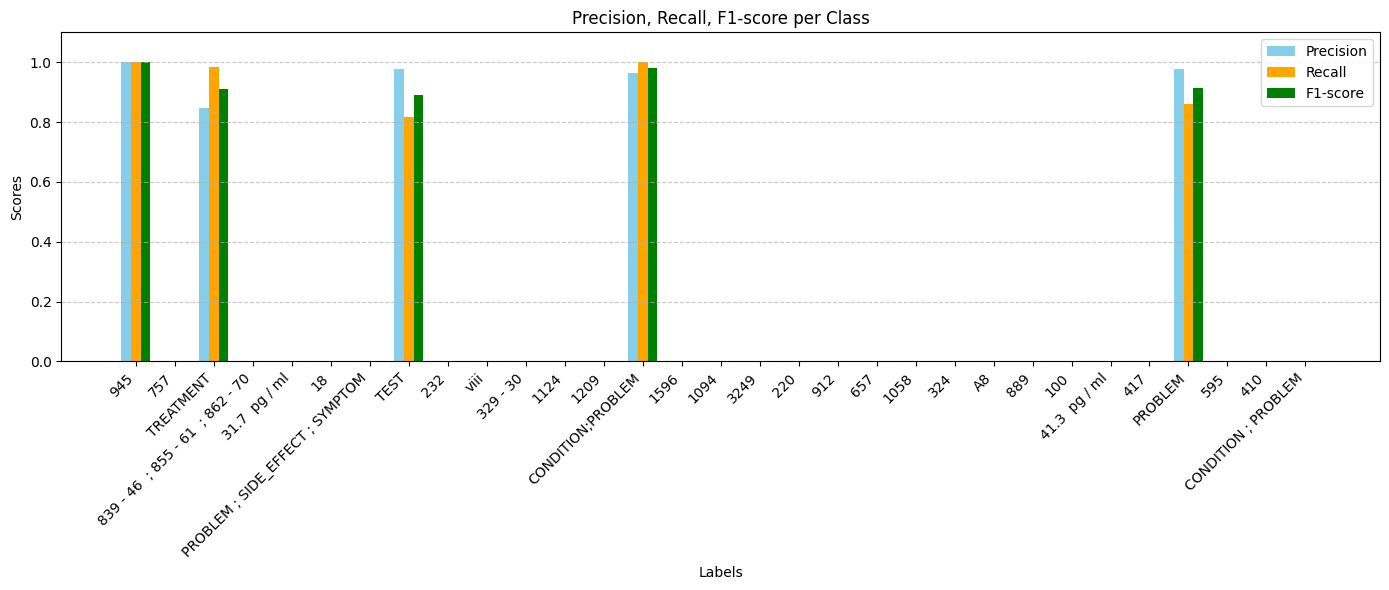

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Generate the classification report as a dictionary
report = classification_report(y_true_flat, y_pred_flat, labels=tags, output_dict=True)

# Extract class-wise precision, recall, f1-score
classes = list(report.keys())[:-3]  # Remove 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1 = [report[cls]['f1-score'] for cls in classes]

x = np.arange(len(classes))  # Label locations
width = 0.25  # Width of bars

# Create subplots
plt.figure(figsize=(14, 6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='orange')
plt.bar(x + width, f1, width, label='F1-score', color='green')

# Add labels and title
plt.xlabel('Labels')
plt.ylabel('Scores')
plt.title('Precision, Recall, F1-score per Class')
plt.xticks(x, classes, rotation=45, ha='right')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

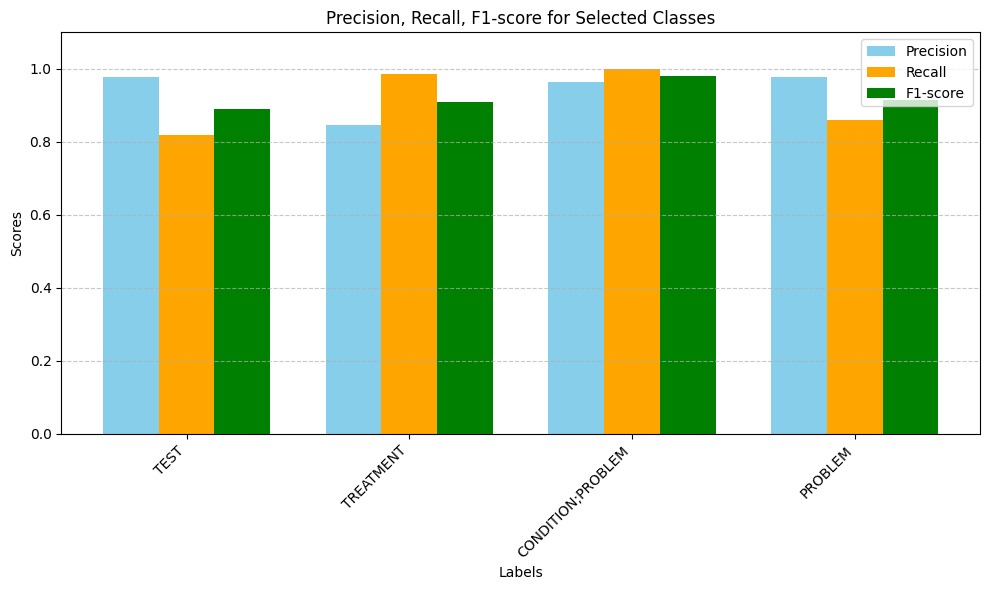

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Generate the classification report as a dictionary
report = classification_report(y_true_flat, y_pred_flat, labels=tags, output_dict=True)

# Specify the target classes to include in the plot
target_classes = ['TEST', 'TREATMENT', 'CONDITION;PROBLEM', 'PROBLEM']

# Extract precision, recall, and f1 for target classes
precision = [report[cls]['precision'] for cls in target_classes]
recall = [report[cls]['recall'] for cls in target_classes]
f1 = [report[cls]['f1-score'] for cls in target_classes]

x = np.arange(len(target_classes))  # Label locations
width = 0.25  # Width of bars

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='orange')
plt.bar(x + width, f1, width, label='F1-score', color='green')

# Add labels and formatting
plt.xlabel('Labels')
plt.ylabel('Scores')
plt.title('Precision, Recall, F1-score for Selected Classes')
plt.xticks(x, target_classes, rotation=45, ha='right')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
